# Telecom Customer Churn Analysis

## Objective:

To analyze telecom customer data to identify key factors influencing churn and build machine learning models to predict customer attrition and support data-driven retention strategies.

## Dataset description

The dataset contains customer information for a telecommunications company and is used to predict customer churn. Each row represents a single customer.

Number of columns: 21

Number of rows: 7043 

Target variable: Churn

### Column Descriptions

customerID:	                Unique identifier for each customer

gender:	                    Customer’s gender (Male or Female)


SeniorCitizen:	            Indicates if the customer is a senior citizen (1 = Yes, 0 = No)


Partner:	                Whether the customer has a partner (Yes / No)


Dependents:	                Whether the customer has dependents (Yes / No)


tenure:	                    Number of months the customer has been with the company


PhoneService:	            Whether the customer has a phone service (Yes / No)


MultipleLines:	            Whether the customer has multiple phone lines (Yes / No / No phone service)


InternetService:	        Customer’s internet service type (DSL, Fiber optic, No)


OnlineSecurity:	            Whether the customer has online security service (Yes / No / No internet service)


OnlineBackup:	            Whether the customer has online backup service (Yes / No / No internet service)


DeviceProtection:	        Whether the customer has device protection (Yes / No / No internet service)


TechSupport:	            Whether the customer has tech support (Yes / No / No internet service)


StreamingTV:	            Whether the customer has streaming TV service (Yes / No / No internet service)


StreamingMovies:	        Whether the customer has streaming movies service (Yes / No / No internet service)


Contract:	                Type of contract (Month-to-month, One year, Two year)


PaperlessBilling:	        Whether the customer uses paperless billing (Yes / No)


PaymentMethod:	            Customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))


MonthlyCharges:	            Monthly charge amount for the customer


TotalCharges:	            Total charge amount for the customer


Churn(Target variable):     indicates if the customer left the company (Yes / No)

In [51]:
# Import required libraries for data analysis and modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [52]:
# Load data from CSV file
df=pd.read_csv(r"C:\Users\iqrai\OneDrive\Desktop\Projects\Customer Churn Analysis & prediction\Telco-Customer-Churn-Data.csv.csv")

In [53]:
# Display the first few rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
# Display the structure of the dataset
df.shape

(7043, 21)

In [55]:
# Display summary information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
# Display statistical summary of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [57]:
# Convert 'TotalCharges' column from object to numeric (float) for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [58]:
# Verify the data type of the 'TotalCharges' column after conversion
df['TotalCharges'].dtype

dtype('float64')

In [59]:
# Check the dataset for missing or null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [60]:
# Handle missing values in 'TotalCharges' based on customer tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

In [61]:
# Recheck the dataset for any remaining null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [62]:
# Check unique values in the 'SeniorCitizen' column
df['SeniorCitizen'].unique()

array([0, 1], dtype=int64)

In [63]:
# Check the data type of the 'SeniorCitizen' column
df['SeniorCitizen'].dtype

dtype('int64')

In [64]:
# Convert 'SeniorCitizen' values from 0 and 1 to 'No' and 'Yes' for better readability
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:'No', 1:'Yes'})
df['SeniorCitizen']

0        No
1        No
2        No
3        No
4        No
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: SeniorCitizen, Length: 7043, dtype: object

In [65]:
# Verify unique values in the 'SeniorCitizen' column after conversion
df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [66]:
# Drop the 'customerID' column since it does not contribute to the analysis
df.drop('customerID', axis=1, inplace=True)

In [67]:
# Preview the first 5 rows of the cleaned and preprocessed dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
# Save the cleaned dataset to a CSV file
df.to_csv("Telco-Customer-Churn-Data(Cleaned).csv", index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [69]:
# Load the cleaned dataset from the CSV file into the DataFrame 'df'
df = pd.read_csv(r"Telco-Customer-Churn-Data(Cleaned).csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Analysis & Visualizations

#### 1] Overall Churn Distribution

In [70]:
# Calculate churn percentage distribution
churn_rate = df['Churn'].value_counts(normalize=True)*100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


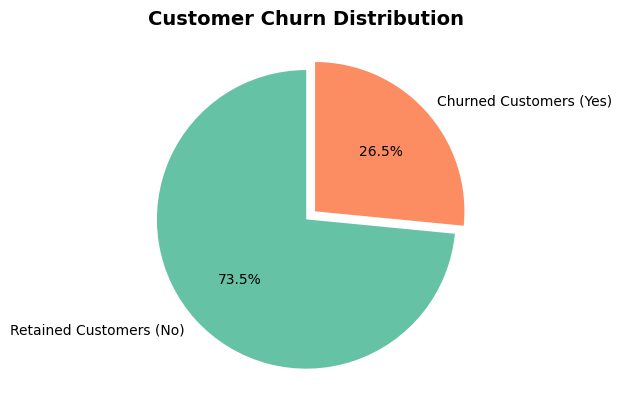

In [71]:
plt.figure(figsize=(6,6))

colors = sns.color_palette('Set2')

plt.pie(
    churn_rate,
    labels=['Retained Customers (No)', 'Churned Customers (Yes)'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.08),
    colors=colors
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight:

Approximately 26.5% of customers have churned.

Nearly 1 in 4 customers leave the company.

Churn represents a significant business risk.

#### 2] Customer Churn Analysis by Gender

In [72]:
# Calculate churn percentage by gender
gender_churn = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


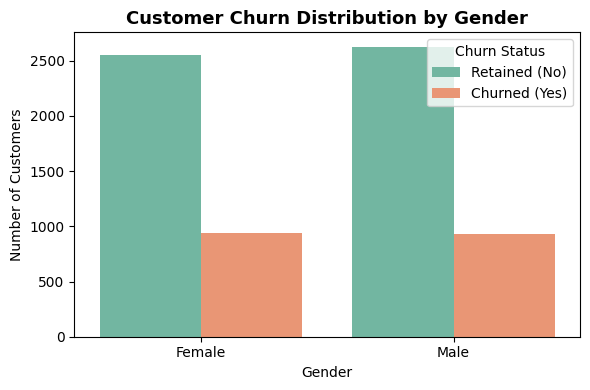

In [73]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='Churn', data=df, palette='Set2')

plt.title("Customer Churn Distribution by Gender", fontsize=13, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Churn rate is nearly equal for male and female customers.

Gender does not significantly influence churn behavior.

Demographics have limited impact on churn.

#### 3] Customer Churn Analysis by Senior Citizen Status

In [74]:
# Calculate churn percentage by Senior Citizen status
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
senior_churn

Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


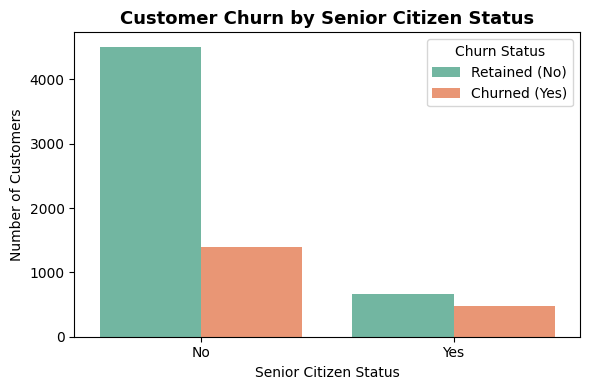

In [75]:
plt.figure(figsize=(6,4))

sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set2')

plt.title("Customer Churn by Senior Citizen Status", fontsize=13, fontweight='bold')
plt.xlabel("Senior Citizen Status")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Senior citizens show a higher churn rate.

Older customers may be more price-sensitive or require stronger support.

Senior status moderately influences churn risk.

#### 4] Customer Churn Analysis by Contract Type

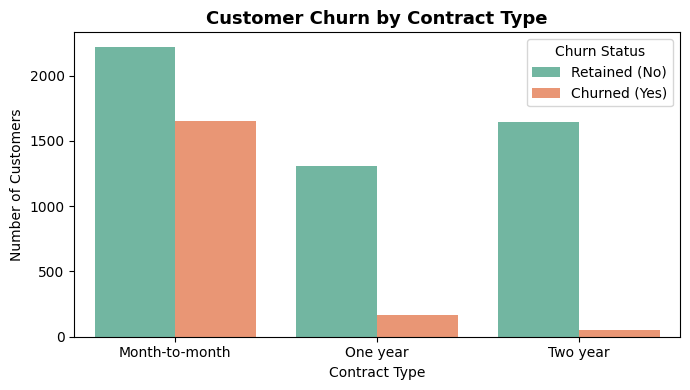

In [76]:
plt.figure(figsize=(7,4))

sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

plt.title("Customer Churn by Contract Type", fontsize=13, fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


#### Insight:

Month-to-month contracts have the highest churn.

Long-term (1-year / 2-year) contracts reduce churn significantly.

Contract type is a major retention driver.

#### 5] Customer Churn Analysis by Payment Method

In [77]:
# Calculate churn percentage by payment method
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


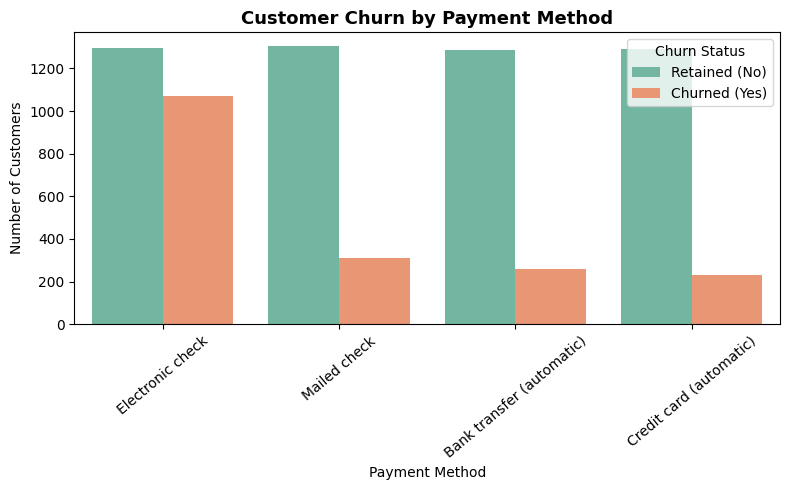

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')

plt.title("Customer Churn by Payment Method", fontsize=13, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=40)

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Electronic check users show higher churn rates.

Automatic payment methods reduce churn risk.

Payment behavior reflects customer commitment.

#### 6] Customer Churn Analysis by Internet Service Type

In [79]:
# Calculate churn percentage by Internet service type
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


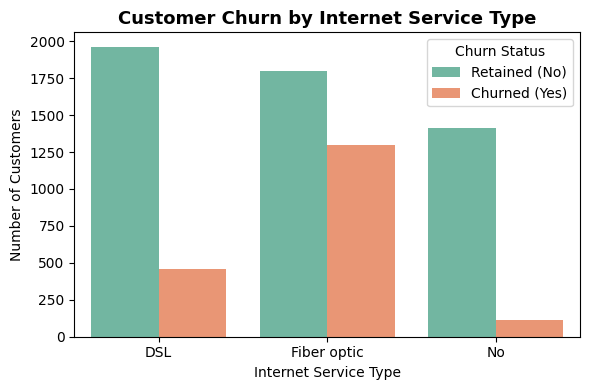

In [80]:
plt.figure(figsize=(6,4))

sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')

plt.title("Customer Churn by Internet Service Type", fontsize=13, fontweight='bold')
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight

Fiber optic users exhibit higher churn.

DSL users show relatively lower churn.

Internet service type significantly impacts churn.

#### 7] Impact of Value-Added Services on Churn

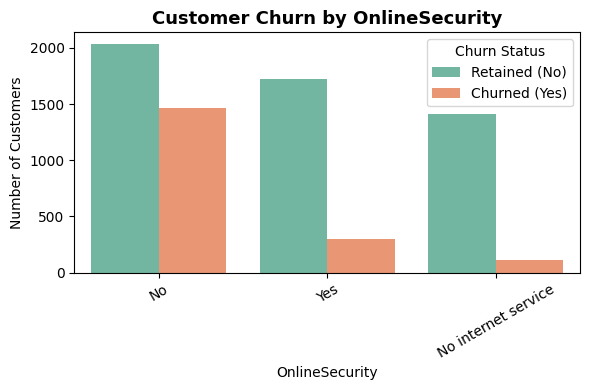

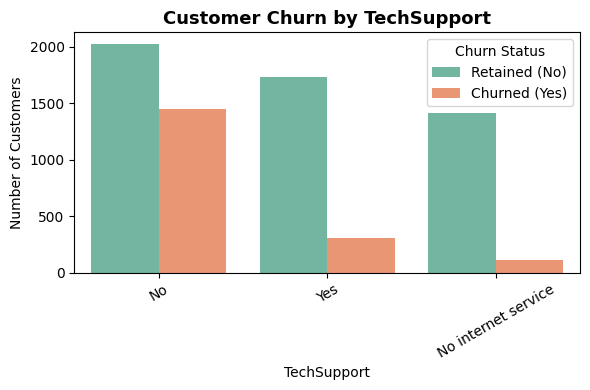

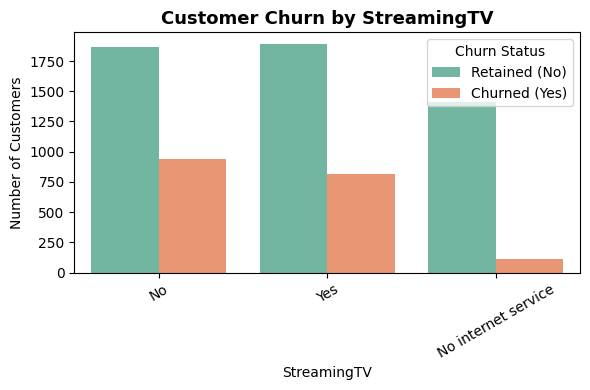

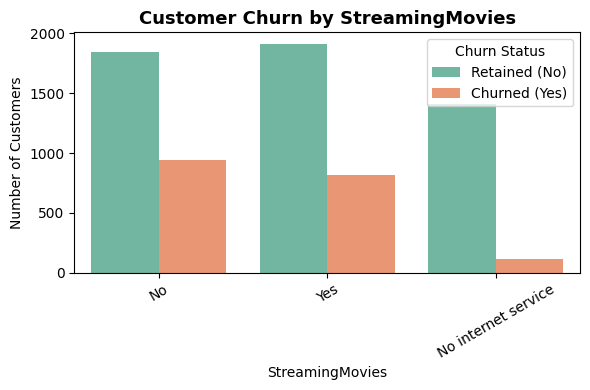

In [81]:
# Analyze churn across different service features
services = ['OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in services:
    plt.figure(figsize=(6,4))
    
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    
    plt.title(f"Customer Churn by {col}", fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    
    plt.xticks(rotation=30)
    plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])
    
    plt.tight_layout()
    plt.show()

#### Insight:

Customers without Online Security or Tech Support churn more.

Value-added services improve retention.

Core support services matter more than entertainment add-ons.

#### 8] Tenure Distribution by Churn Status

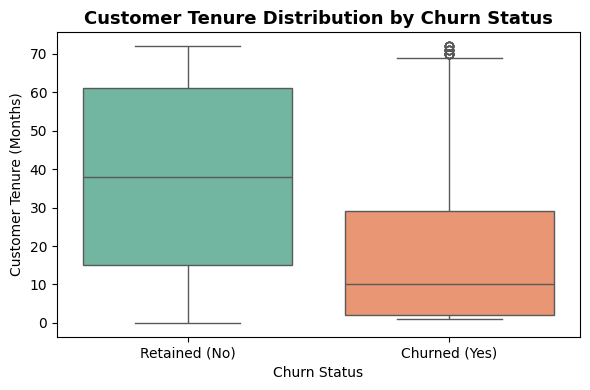

In [82]:
plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')

plt.title("Customer Tenure Distribution by Churn Status", fontsize=13, fontweight='bold')
plt.xlabel("Churn Status")
plt.ylabel("Customer Tenure (Months)")

plt.xticks([0,1], ["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Customers with low tenure churn more frequently.

Long-term customers demonstrate strong loyalty.

Churn is highest among newly acquired customers.

#### 9] Monthly Charges Distribution by Churn

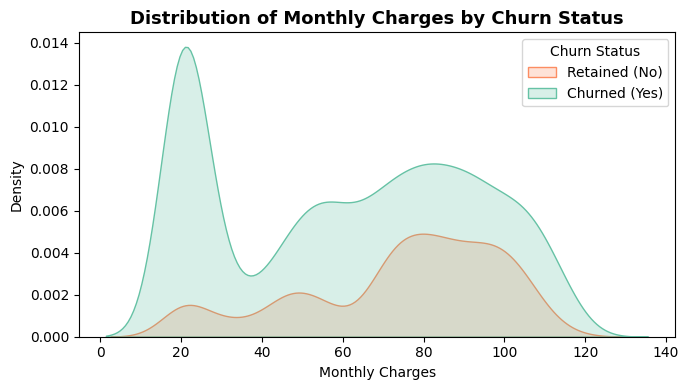

In [83]:
plt.figure(figsize=(7,4))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette='Set2')

plt.title("Distribution of Monthly Charges by Churn Status", fontsize=13, fontweight='bold')
plt.xlabel("Monthly Charges")
plt.ylabel("Density")

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Higher monthly charges are associated with higher churn.

Price-sensitive customers are more likely to leave.

Retained customers are concentrated in lower pricing tiers.

#### 10] Total Charges Distribution by Churn

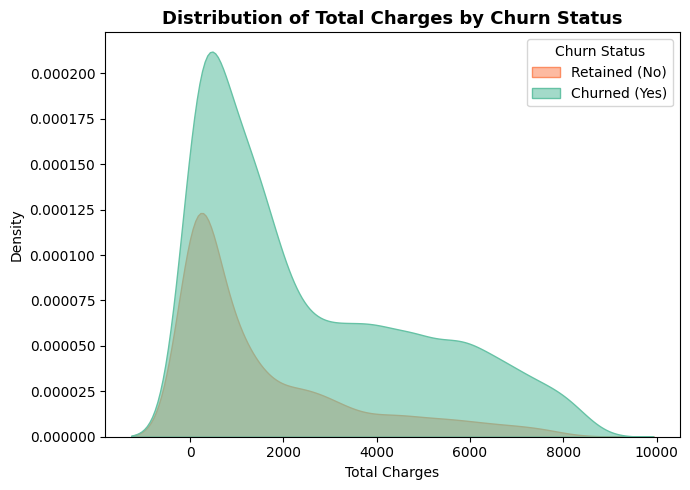

In [84]:
plt.figure(figsize=(7,5))

sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, palette='Set2', alpha=0.6)

plt.title("Distribution of Total Charges by Churn Status", fontsize=13, fontweight='bold')
plt.xlabel("Total Charges")
plt.ylabel("Density")

plt.legend(title="Churn Status", labels=["Retained (No)", "Churned (Yes)"])

plt.tight_layout()
plt.show()

#### Insight:

Churned customers have lower TotalCharges.

Lower total charges are mainly due to lower tenure.

TotalCharges reflects customer lifetime value.

#### 11] Correlation Analysis of Numerical Features

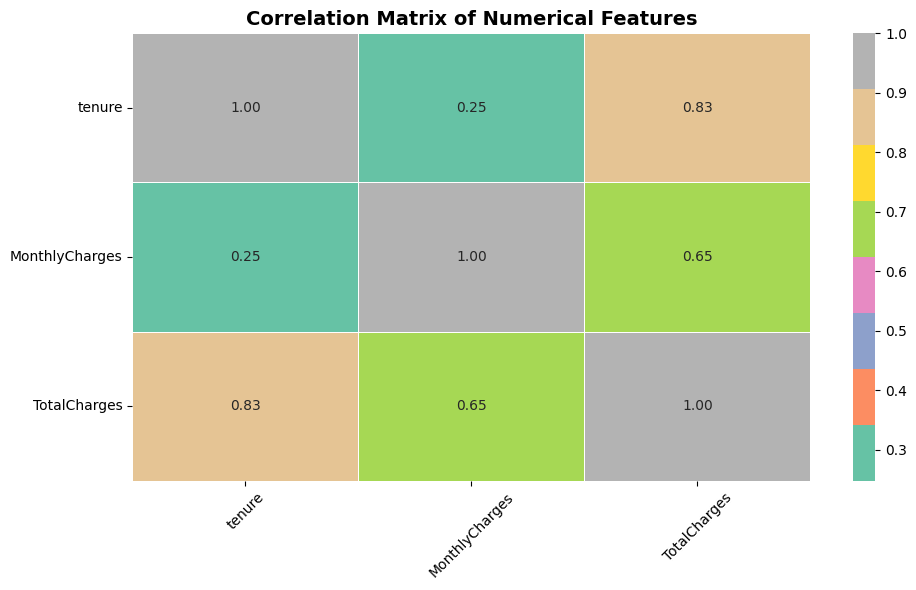

In [85]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap=sns.color_palette("Set2", as_cmap=True),
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


#### Insight:

Tenure and TotalCharges have strong positive correlation (0.83).

MonthlyCharges moderately impacts TotalCharges (0.65).

Tenure is the most important numeric factor for retention.

#### 12] Key Drivers of Customer Churn

In [86]:
import pandas as pd

categorical_cols = [
    'gender','SeniorCitizen','Partner','Dependents',
    'PhoneService','MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','PaperlessBilling','PaymentMethod','Contract'
]

impact_scores = {}

for col in categorical_cols:
    churn_rate = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    
    if 'Yes' in churn_rate.columns:
        diff = churn_rate['Yes'].max() - churn_rate['Yes'].min()
        impact_scores[col] = diff

impact_df = pd.DataFrame.from_dict(
    impact_scores, orient='index', columns=['ChurnRateDifference']
)

impact_df = impact_df.sort_values(by='ChurnRateDifference', ascending=False)

impact_df

,ChurnRateDifference
Contract,39.877819
InternetService,34.487785
OnlineSecurity,34.361744
TechSupport,34.230493
OnlineBackup,32.523776
DeviceProtection,31.722645
PaymentMethod,30.042311
SeniorCitizen,18.075092
PaperlessBilling,17.235009
Dependents,15.828904


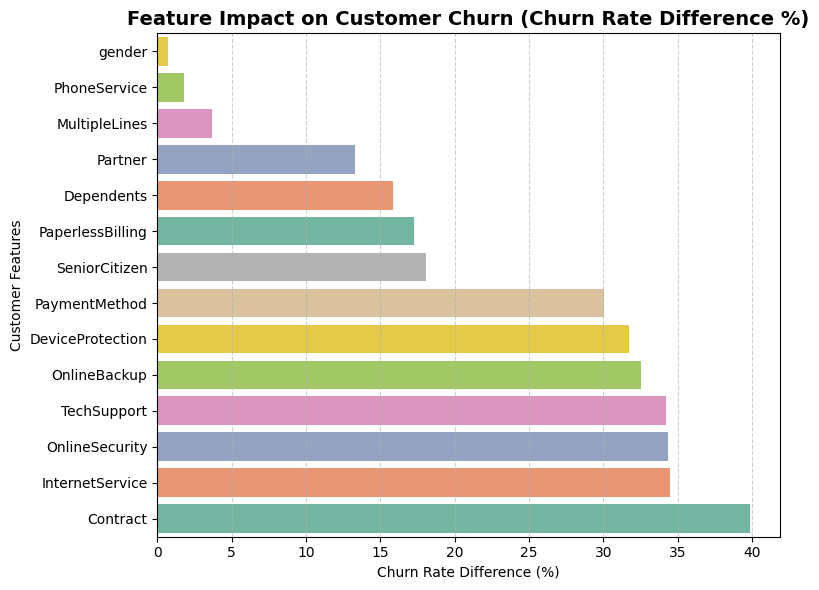

In [87]:
plt.figure(figsize=(8,6))

values = impact_df.squeeze()   # ensures 1D values

sns.barplot(
    x=values,
    y=values.index,
    palette='Set2'
)

plt.title("Feature Impact on Customer Churn (Churn Rate Difference %)", fontsize=14, fontweight='bold')
plt.xlabel("Churn Rate Difference (%)")
plt.ylabel("Customer Features")

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Insight:

Contract type is the strongest driver of churn.

Service engagement significantly affects retention.

Demographic factors have minimal influence.

## EDA Summary

1. Approximately 26.5% of customers churn, indicating a meaningful retention challenge.

2. Contract type is the strongest driver of churn, with month-to-month customers at highest risk.

3. Service engagement (Online Security, Tech Support, Backup, Device Protection) significantly reduces churn.

4. Fiber optic users and electronic check customers exhibit higher churn rates.

5. Higher monthly charges increase churn likelihood.

6. Tenure is the most critical numeric factor — long-term customers show strong loyalty.

7. Demographic factors such as gender have minimal impact.

8. Overall, churn is primarily driven by service usage, pricing structure, and contract commitment rather than demographics.

## Business Recommendations

1. Offer incentives for customers to move from month-to-month to yearly contracts.

2. Improve service quality and pricing strategies for fiber optic internet users.

3. Introduce loyalty programs for customers with high monthly charges.

4. Implement early engagement programs for new customers to improve retention.

5. Promote automatic payment methods through discounts and rewards.

6. Provide dedicated support for senior citizen customers.

7. Deploy a churn prediction model to identify at-risk customers and take proactive retention actions.

# Predictive Modeling

Let's Clean and Prepare the Data for the Machine Learning Model

In [136]:
# Load data from CSV file
df=pd.read_csv(r"Telco-Customer-Churn-Data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [137]:
# Convert 'TotalCharges' from object to numeric (float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [138]:
# Fill missing values in 'TotalCharges' using tenure-based logic

df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

In [139]:
# Check the dataset for missing or null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [140]:
# Convert 'Churn' from categorical (Yes/No) to binary values (1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [141]:
# Remove customerID (unique identifier, not needed for modeling)
df = df.drop('customerID', axis=1)

## Encoding Categorical Variables

In [142]:
# One-hot encode categorical variables (drop first to prevent dummy variable trap)
df_encoded = pd.get_dummies(df, drop_first=True)

In [143]:
# Preview the first few rows of the encoded dataset
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [144]:
# Separate features (X) and target variable (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [145]:
# Split the dataset into training and testing sets (80% train, 20% test) using stratified sampling

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

## Feature Scaling Using StandardScaler

In [146]:
# Standardize feature values using StandardScaler (fit on training data, transform both sets)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression (Base Model)

We start with Logistic Regression as a baseline model to predict customer churn.

In [147]:
# Train a Logistic Regression model on the scaled training data

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [148]:
# Generate predicted class labels and predicted probabilities for the test set

y_pred = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [149]:
# Evaluate model performance using accuracy, classification report, confusion matrix, and ROC-AUC score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8069552874378992

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
 [[925 110]
 [162 212]]

ROC-AUC Score: 0.842771706838203


In [150]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

## Random Forest (Base Model)

Next, we train a Random Forest model to capture complex patterns and improve churn prediction.

In [152]:
# Train a Random Forest classifier on the training data

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [153]:
# Generate predicted class labels and predicted probabilities using the Random Forest model

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [154]:
# Evaluate Random Forest model performance using accuracy, classification report, confusion matrix, and ROC-AUC score

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7849538679914834

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


Confusion Matrix:
 [[920 115]
 [188 186]]

ROC-AUC Score: 0.8253313182980704


## Random Forest (Hyperparameter Tuned Model)

Next, we improve the Random Forest model by tuning its hyperparameters to achieve better performance.

In [155]:
# Perform hyperparameter tuning for Random Forest using GridSearchCV to find the best model based on ROC-AUC score

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [156]:
# Apply a custom probability threshold (0.35) to convert predicted probabilities into class labels

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:,1]
y_pred_custom = (y_prob_rf_tuned > 0.35).astype(int)

In [157]:
# Evaluate the Random Forest model using key performance metrics

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7849538679914834

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


Confusion Matrix:
 [[920 115]
 [188 186]]

ROC-AUC Score: 0.8253313182980704


## Model Performance Comparison

Compare the performance of all models to select the best one.

In [161]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Logistic Regression metrics
log_acc = accuracy_score(y_test, y_pred)
log_pre = precision_score(y_test, y_pred)
log_rec = recall_score(y_test, y_pred)
log_auc = roc_auc_score(y_test, y_prob_log)

# Random Forest metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_pre = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

# Tuned Random Forest metrics
trf_acc = accuracy_score(y_test, y_pred_custom)
trf_pre = precision_score(y_test, y_pred_custom)
trf_rec = recall_score(y_test, y_pred_custom)
trf_auc = roc_auc_score(y_test, y_prob_rf_tuned)

# Model comparison table
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [log_acc, rf_acc, trf_acc],
    "Precision": [log_pre, rf_pre, trf_pre],
    "Recall": [log_rec, rf_rec, trf_rec],
    "ROC-AUC": [log_auc, rf_auc, trf_auc]
})

model_comparison.round(3)


,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.807,0.658,0.567,0.842
1,Random Forest,0.785,0.618,0.497,0.825
2,Tuned Random Forest,0.720,0.484,0.850,0.843


## Final Model Selection

Three models were evaluated: Logistic Regression, Random Forest, and Tuned Random Forest.

Logistic Regression achieved the highest accuracy (0.807) and precision (0.658),
indicating strong overall predictive performance.

However, the Tuned Random Forest model achieved the highest recall (0.850),
meaning it successfully identified the majority of customers likely to churn.

Since the primary objective of churn prediction is to detect as many potential
churn customers as possible, the Tuned Random Forest model was selected as the
final model despite its lower accuracy.

## Customer Churn Prediction Function

In [96]:
# Select the tuned Random Forest model as the final model
final_model = best_rf   

In [97]:
# Function to predict customer churn using a final model

def predict_churn(input_data, model, feature_columns):
    """
    input_data: dictionary of customer features
    model: trained model
    feature_columns: X_train.columns
    """
    
    import pandas as pd
    
    # Convert dictionary to dataframe
    input_df = pd.DataFrame([input_data])
    
    # One-hot encode
    input_encoded = pd.get_dummies(input_df)
    
    # Align columns with training data
    input_encoded = input_encoded.reindex(columns=feature_columns, fill_value=0)
    
    # Predict probability
    prob = model.predict_proba(input_encoded)[:,1][0]
    
    # Predict class (threshold 0.5)
    prediction = 1 if prob > 0.5 else 0
    
    return {
        "Churn Prediction": "Yes" if prediction == 1 else "No",
        "Churn Probability": round(prob, 3)
    }

In [98]:
# Predict churn for a sample customer using the trained model and aligned feature columns
sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.5,
    'TotalCharges': 1020.5
}

predict_churn(sample_customer, final_model, X.columns)

{'Churn Prediction': 'Yes', 'Churn Probability': 0.811}

## Conclusion:

The project successfully identified key drivers of telecom customer churn.
Contract type, tenure, and value-added services significantly impact retention.
The tuned Random Forest model achieved the best recall for churn detection,
making it the most suitable model for customer retention strategies.